# Dynamic Ripeness Prediction for Banana Supply Chain Optimization

- **Problem Statement:**

Globally shipped bananas are highly perishable. Up to 20% of harvested fruit is lost before reaching consumers because they ripen too quickly or unevenly during transport. Traditional supply chains rely on fixed temperature schedules that do not account for variations in fruit age, route delays, or unexpected sensor fluctuations. This results in standard shipping containers arriving with mixed-quality fruit: some unripe (too hard to sell), some perfect, and some overripe (waste).

- **The Machine Learning Goal:**

Build a supervised learning regression model that utilizes real-time environmental data to continuously forecast the Ripeness State of bananas within a specific container at any future point on its journey.

- **How the Business Solves It:**

Instead of a "dumb" container that just maintains a set temperature, the ML-powered system creates a Dynamic Optimizer. If the ML model predicts that a shipment will arrive 3 days early or 2 days late to its perfect ripeness window, the logistics manager can:

1. Adjust Temperatures remotely: Slow down or speed up ripening.

2. Reroute Ships: Divert a fast-ripening shipment to a closer port.

3. Optimize Inventory: Prioritize early-arriving bananas for immediate distribution.

### 1. Environment Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('banana_ripeness_raw.csv')
df.head()

,Container_ID,Snapshot_Age_Days,Origin_Port,Days_to_Destination,Avg_Temp_C,Humidity_Pct,CO2_ppm,Initial_Ripeness_Image_Score,Transport_Delay_Events,Ripeness_Index
0,C001,0.0,Guayaquil,14.0,13.2,85,450,1.5,0,1.5
1,C001,0.5,Guayaquil,13.5,13.2,85,455,1.5,0,1.6
2,C001,1.0,Guayaquil,13.0,13.3,86,470,1.5,0,1.6
3,C002,0.0,Puerto_Bolivar,18.0,13.0,84,400,1.2,0,1.2
4,C002,0.5,Puerto_Bolivar,17.5,13.1,84,402,1.2,0,1.2


### The Raw, Synthetic Dataset

This dataset represents "snapshots" taken every 12 hours from smart sensors located inside fictional shipping containers.

The model would take a snapshot of features (the first 8 columns) and try to predict the Ripeness_Index at that specific moment. In a real-world scenario, you would also use historical snapshots to predict future index values.

Target Definition: Ripeness Index
We will use a numerical target instead of simple classes (Ripe/Unripe) to provide higher granularity.

- 0.0 - 2.0: Unripe (Green)

- 2.1 - 4.0: Light Green/Yellow (Turning)

- 4.1 - 6.0: Perfect Ripe (Yellow)

- 6.1 - 8.0: Overripe (Yellow with Brown spots)

- Greater than 8.0: Rotten (Waste)

### 2. Exploratory Data Analysis (EDA)
Before training, we need to understand the relationships. We expect `CO2_ppm` and `Avg_Temp_C` to be major drivers of ripening.

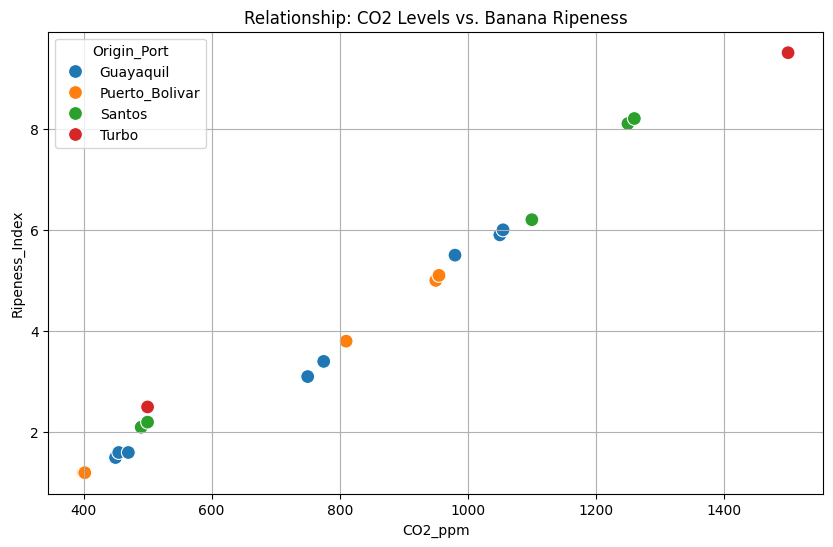

In [5]:
# Visualize the relationship between CO2 levels and Ripeness
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='CO2_ppm', y='Ripeness_Index', hue='Origin_Port', s=100)
plt.title('Relationship: CO2 Levels vs. Banana Ripeness')
plt.grid(True)
plt.show()

### 3. Preprocessing (Feature Engineering)

Machines don't speak "English," so we must convert the `Origin_Port` text into numbers and separate our **Features (X)** from our **Target (y)**.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. One-Hot Encode the 'Origin_Port'
df_encoded = pd.get_dummies(df, columns=['Origin_Port'])

# 2. Drop unique IDs that don't help prediction
X = df_encoded.drop(['Container_ID', 'Ripeness_Index'], axis=1)
y = df_encoded['Ripeness_Index']

# 3. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")

Training shapes: (16, 11), Testing shapes: (4, 11)


### 4. Model Training

We will use a **Random Forest Regressor**. It’s excellent for small datasets because it combines multiple decision trees to find complex patterns without "overfitting" too easily.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


### 5. Evaluation
How accurate is our "Ripening Engine"? We use **Root Mean Squared Error (RMSE)** to see how many "Ripeness Points" we are off on average.

In [8]:
# Make predictions on the test set
predictions = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"RMSE: {rmse:.4f} (On a scale of 0-10)")
print(f"R2 Score: {r2:.4f} (Accuracy Percentage)")

# Compare actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})
print("\nSample Predictions:")
print(comparison.head())

RMSE: 0.3839 (On a scale of 0-10)
R2 Score: 0.9809 (Accuracy Percentage)

Sample Predictions:
    Actual  Predicted
0      1.5      1.735
17     8.2      7.500
15     5.1      4.947
1      1.6      1.745


### 6. Business Application: The "Ripeness Alert"

Now we can write a function that takes new sensor data and tells us if the bananas are at risk of spoiling before they arrive.

In [9]:
def check_banana_status(prediction):
    if prediction > 8.0:
        return "⚠️ CRITICAL: SPOILED"
    elif prediction > 6.0:
        return "⚠️ WARNING: OVERRIPE (Divert to nearest port)"
    elif prediction > 4.0:
        return "✅ PERFECT: READY FOR MARKET"
    else:
        return "🕒 STATUS: UNRIPE (Continue shipping)"

# Test it on a random row from our test set
sample_pred = predictions[0]
print(f"Predicted Index: {sample_pred:.2f}")
print(f"Action Required: {check_banana_status(sample_pred)}")

Predicted Index: 1.73
Action Required: 🕒 STATUS: UNRIPE (Continue shipping)
